DATA603: Principles of Machine Learning - Final Term Project

**A COMPREHENSIVE STUDY OF MACHINE LEARNING MODELS FOR CROSS-SITE SCRIPTING DETECTION**

*Name: Madhumitha Rajagopal*

*UID: 121331472*

##**RNN MODEL**

This is the code snippet for the RNN model on the XSS Dataset.

### Import Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import glob
import time
import pandas as pd
# from xml.dom import minidom
import os
import matplotlib.pyplot as plt
import keras
import cv2

In [2]:
# Load the dataset into a DataFrame
df=pd.read_csv('/content/XSS_dataset.csv', encoding='utf-8-sig')

In [3]:
# first 5 rows of the DataFrame
df.head()

,Unnamed: 0,Sentence,Label
0,0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,2,"\t </span> <span class=""reference-text"">Steeri...",0
3,3,"\t </span> <span class=""reference-text""><cite ...",0
4,4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [4]:
# Only get sentence and labels
df=df[df.columns[-2:]]

In [5]:
# Display the first 5 rows of the DataFrame
df.head()

,Sentence,Label
0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,"\t </span> <span class=""reference-text"">Steeri...",0
3,"\t </span> <span class=""reference-text""><cite ...",0
4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [6]:
# Get Sentences data from data frame
sentences=df['Sentence'].values
sentences[1]

'<tt onmouseover="alert(1)">test</tt>'

In [7]:
# Print the total number of sentences in the 'Sentence' column
print(len(sentences))

13686


In [8]:
# Function to convert a sentence to an ASCII representation with normalization
# This function replaces specific Unicode characters with designated ASCII values and normalizes the remaining characters that are within certain ranges.

def convert_to_ascii(sentence):
    sentence_ascii = []
    for i in sentence:
        if ord(i) < 8222:  # Adjusted condition
            if ord(i) == 8221:  # ” : 8221
                sentence_ascii.append(129)
            elif ord(i) == 8220:  # “ : 8220
                sentence_ascii.append(130)
            elif ord(i) == 8216:  # ‘ : 8216
                sentence_ascii.append(131)
            elif ord(i) == 8217:  # ’ : 8217
                sentence_ascii.append(132)
            elif ord(i) == 8211:  # – : 8211
                sentence_ascii.append(133)
            else:
                sentence_ascii.append(ord(i))
    zer = np.zeros((10000))
    for i in range(len(sentence_ascii)):
        zer[i] = sentence_ascii[i]
    zer.shape = (100, 100)
    return zer

In [9]:
# Convert sentences into 3D array representations of images
# Each sentence is processed into a 100x100 ASCII matrix, resized, and normalized.

arr=np.zeros((len(sentences),100,100))

for i in range(len(sentences)):

    image=convert_to_ascii(sentences[i])

    x=np.asarray(image,dtype='float')
    image =  cv2.resize(x, dsize=(100,100), interpolation=cv2.INTER_CUBIC)
    image/=128

#     if i==1:
#         plt.plot(image)
#         plt.show()
    arr[i]=image

In [10]:
print("Input data shape : ", arr.shape)

Input data shape :  (13686, 100, 100)


In [11]:
# Reshape the 3D array to include a channel dimension for compatibility with deep learning models
# The array is reshaped to have the shape (number of sentences, 100, 100, 1), where 1 represents the grayscale channel.
data = arr.reshape(arr.shape[0], 100, 100, 1)

In [12]:
data.shape

(13686, 100, 100, 1)

In [13]:
# Extract the 'Label' column from the DataFrame
y=df['Label'].values

In [14]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
trainX, testX, trainY, testY = train_test_split(data,y, test_size=0.2, random_state=42)
trainX, validX, trainY, validY = train_test_split(trainX,trainY, test_size=0.2, random_state=42)

In [15]:
# Import libraries for Making Model
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Activation, Conv2D, MaxPooling2D,Flatten,Dropout,MaxPool2D, BatchNormalization

In [16]:
# Bidirectional RNN Model Architecture with TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Bidirectional

# Define the model
model = Sequential([
    Bidirectional(SimpleRNN(64, activation='relu', return_sequences=True), input_shape=(100, 100)),

    # Add dropout for regularization if needed
    # tf.keras.layers.Dropout(0.2),

    Bidirectional(SimpleRNN(128, activation='relu', return_sequences=True)),
    Bidirectional(SimpleRNN(256, activation='relu', return_sequences=True)),

    # Add more SimpleRNN layers if needed

    # Flatten the output of the RNN layers
    tf.keras.layers.Flatten(),

    # Dense layers
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])



/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 100, 128)            │          21,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 100, 256)            │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 100, 512)            │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      13,107,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,498,241 (51.49 MB)

 Trainable params: 13,498,241 (51.49 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Reshape input data to have 3 dimensions
trainX_reshaped = trainX.reshape(trainX.shape[0], trainX.shape[1], trainX.shape[2])

# Define batch size and number of epochs
batch_size = 128
num_epochs = 10

validX_reshaped = validX.reshape(validX.shape[0], validX.shape[1], validX.shape[2])

# Model training
model_log = model.fit(trainX_reshaped, trainY,
                      batch_size=batch_size,
                      epochs=num_epochs,
                      verbose=1,
                      validation_data=(validX_reshaped, validY))

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.7937 - loss: 0.3867 - val_accuracy: 0.9735 - val_loss: 0.0973
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.9706 - loss: 0.0908 - val_accuracy: 0.9749 - val_loss: 0.0699
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9817 - loss: 0.0578 - val_accuracy: 0.9822 - val_loss: 0.0616
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9852 - loss: 0.0508 - val_accuracy: 0.9717 - val_loss: 0.1033
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9851 - loss: 0.0463 - val_accuracy: 0.9808 - val_loss: 0.0597
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.9868 - loss: 0.0410 - val_accuracy: 0.9826 - val_loss: 0.0656
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9873 - loss: 0.0379 - val_accuracy: 0.9817 - val_loss: 0.0551
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.9897 - loss: 0.0343 - val_accuracy: 0.982

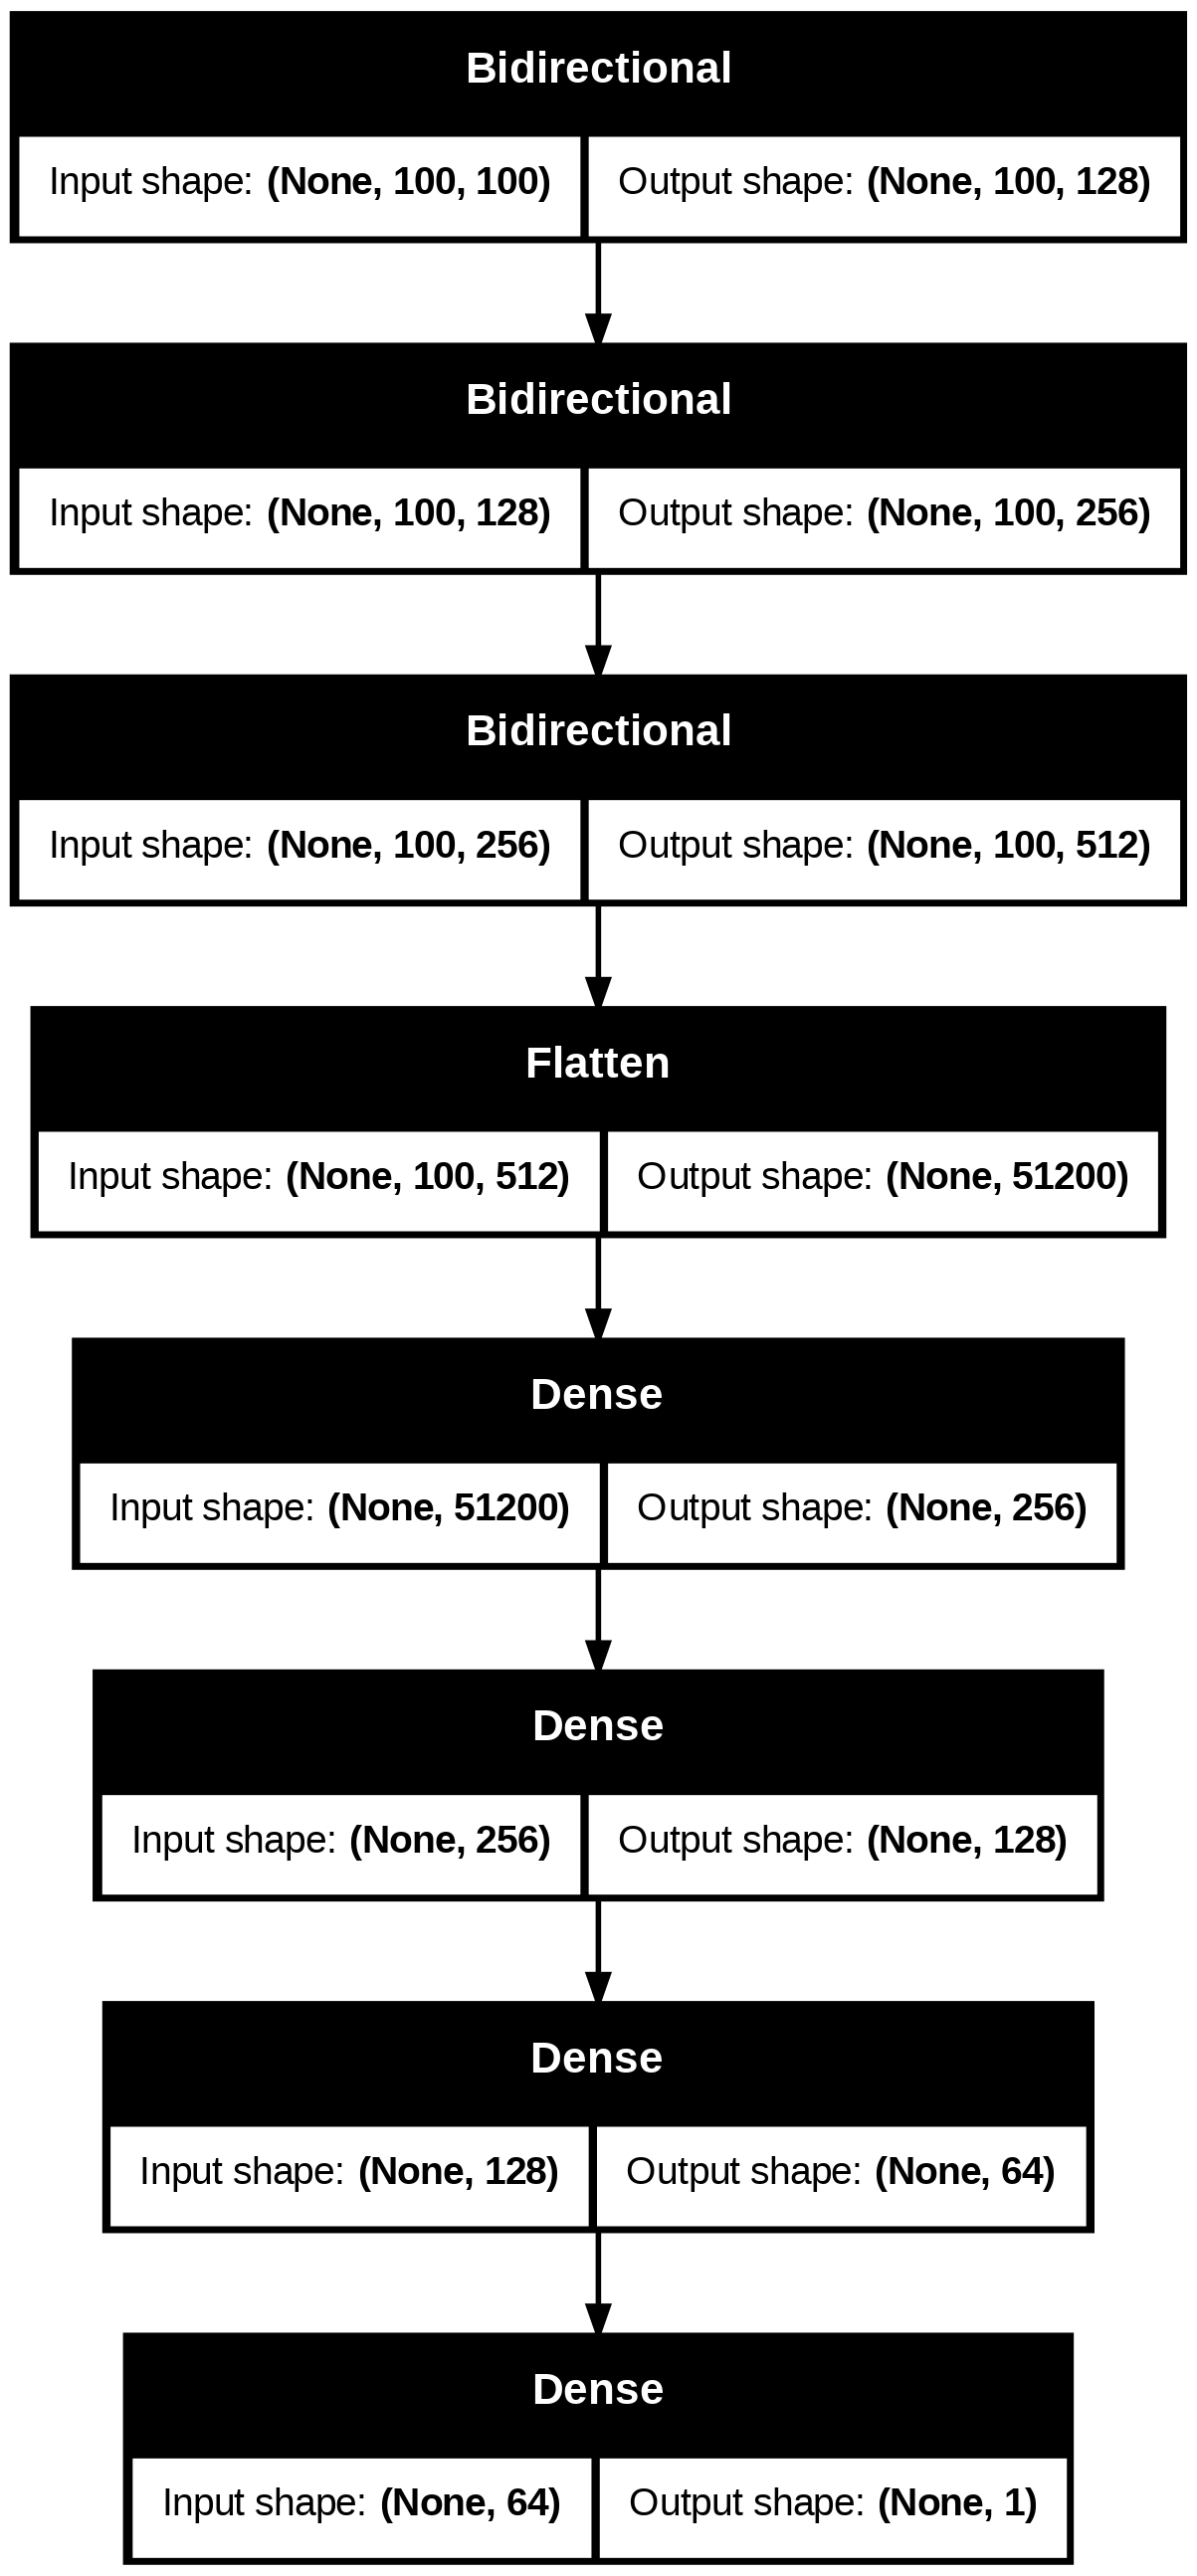

In [19]:
# Plot model architecture
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='rnn_model.png', show_shapes=True)

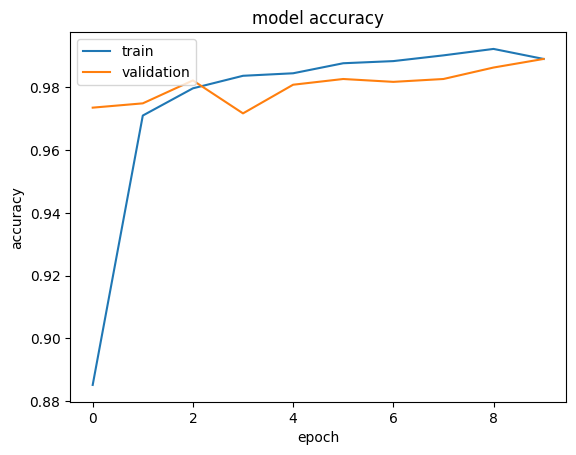

In [20]:
#Plot Training and Validation Accuracy Over Epochs
def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()
plot_hist(model_log)

69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step


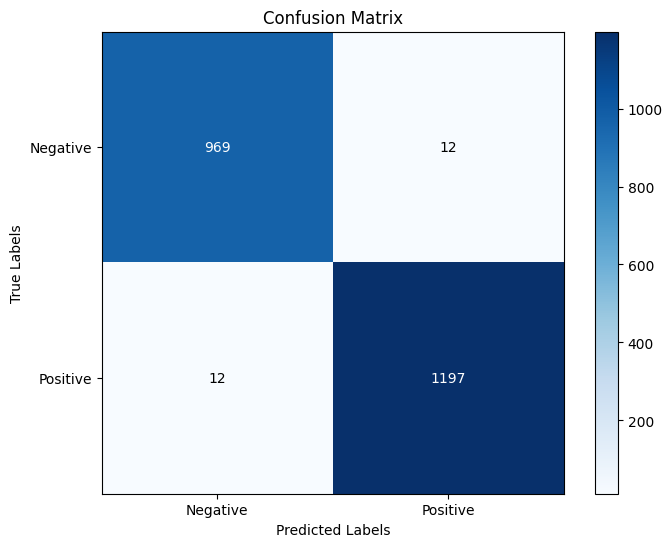

Classification Report:
              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99       981
    Positive       0.99      0.99      0.99      1209

    accuracy                           0.99      2190
   macro avg       0.99      0.99      0.99      2190
weighted avg       0.99      0.99      0.99      2190



In [21]:
# Confusion Matrix Visualization and Classification Report for Model Evaluation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have already trained your model and obtained predictions
predictions = model.predict(validX_reshaped)

# Convert predictions to binary labels (0 or 1)
binary_predictions = np.round(predictions)

# Get the confusion matrix
conf_matrix = confusion_matrix(validY, binary_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

# Add labels to each cell
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.show()

# Generate classification report
class_report = classification_report(validY, binary_predictions, target_names=['Negative', 'Positive'])
print("Classification Report:")
print(class_report)


In [22]:
# Save the model
model.save('rnn_model.h5')
loaded_model = tf.keras.models.load_model('rnn_model.h5')

In [23]:
def convert_to_ascii(sentence):
    sentence_ascii = []
    for i in sentence:
        if ord(i) < 8222:  # Adjusted condition
            if ord(i) == 8221:  # ” : 8221
                sentence_ascii.append(129)
            elif ord(i) == 8220:  # “ : 8220
                sentence_ascii.append(130)
            elif ord(i) == 8216:  # ‘ : 8216
                sentence_ascii.append(131)
            elif ord(i) == 8217:  # ’ : 8217
                sentence_ascii.append(132)
            elif ord(i) == 8211:  # – : 8211
                sentence_ascii.append(133)
            else:
                sentence_ascii.append(ord(i))
    zer = np.zeros((10000))
    for i in range(len(sentence_ascii)):
        zer[i] = sentence_ascii[i]
    zer.shape = (100, 100)
    return zer


def predict(sentence):
    image=convert_to_ascii(sentences[i])
    x=np.asarray(image,dtype='float')
    vec =  cv2.resize(x, dsize=(100,100), interpolation=cv2.INTER_CUBIC)
    vec/=128
    reshaped_vector = vec.reshape(1, 100, 100)
    return 1 if model.predict(reshaped_vector)[0][0] >= 0.5 else 0

In [25]:
# Function to Predict and Return Probability for a Given Sentence Using Preprocessed ASCII Image Input
def predict(sentence):
    image=convert_to_ascii(sentence)
    x=np.asarray(image,dtype='float')
    vec =  cv2.resize(x, dsize=(100,100), interpolation=cv2.INTER_CUBIC)
    vec/=128
    reshaped_vector = vec.reshape(1, 100, 100)
    # Get the prediction probability directly instead of using conditional logic
    prediction_probability = model.predict(reshaped_vector)[0][0]
    return prediction_probability

In [26]:
# Evaluate Model Accuracy by Comparing Predictions with True Labels in the Dataset
correct = 0
incorrect = 0
from tqdm import tqdm

for i in tqdm(range(len(df_))):
    sentence = df_.iloc[i]["Sentence"]
    label = df_.iloc[i]["Label"]
    prediction = 0
    # Get the prediction probability directly
    prediction_probability = predict(sentence)
    if prediction_probability >= 0.5:
        prediction = 1
    if prediction==label:
        correct+=1
    else:
        incorrect+=1


print(correct)
print(incorrect)

  0%|          | 0/13686 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step


  0%|          | 1/13686 [00:01<5:00:49,  1.32s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  0%|          | 3/13686 [00:01<1:29:09,  2.56it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


100%|█████████▉| 13684/13686 [21:58<00:00, 10.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


100%|██████████| 13686/13686 [21:58<00:00, 10.38it/s]

13577
109


In [31]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(validY, binary_predictions)
precision = precision_score(validY, binary_predictions)
recall = recall_score(validY, binary_predictions)

# Extract validation accuracy and validation loss from the model's history
validation_accuracy = model_log.history['val_accuracy'][-1]
validation_loss = model_log.history['val_loss'][-1]

# Extract training loss for comparison
training_loss = model_log.history['loss'][-1]

metrics_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Validation Accuracy',
        'Loss',
        'Validation Loss',
        'Precision',
        'Recall'
    ],
    'Value': [
        accuracy,
        validation_accuracy,
        training_loss,
        validation_loss,
        precision,
        recall
    ]
})

# Display the DataFrame
print(metrics_df)


                Metric     Value
0             Accuracy  0.989041
1  Validation Accuracy  0.989041
2                 Loss  0.031572
3      Validation Loss  0.038392
4            Precision  0.990074
5               Recall  0.990074
